# 1. Importación de librerías

In [121]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

# 2. Importación fuente de datos

El dataset está organizado en una carpeta por especie (clasificación multiclase). Se combina
el dataset base (A Large Scale Fish Dataset, Kaggle) con las especies adicionales requeridas
por el proyecto (atún aleta amarilla, corvina reina, dorado, marlín/pez vela, pargo mancha,
tiburón martillo, tortuga marina).

In [122]:
mi_directorio = 'NA_fish_dataset_limpio_limpio'

In [123]:
# Se listan las clases (carpetas) detectadas en el dataset
clases = os.listdir(mi_directorio)
clases

['Atun_Aleta_amarilla_n',
 'Black Sea Sprat',
 'corvina_reina',
 'dorado',
 'pargo_mancha_n',
 'pez_vela_n',
 'Red Mullet',
 'Red Sea Bream',
 'Sea Bass',
 'Shrimp',
 'Striped Red Mullet',
 'tiburon_martillo_n',
 'tortuga_marina_n']

In [124]:
num_classes = len(clases)
print(f'Número de clases: {num_classes}')

Número de clases: 13


# 3. Preprocesado

## 3.1 Distribución y visualización del dataset

In [ ]:
# Cantidad de imágenes 
for clase in clases:
    n_imagenes = len(os.listdir(os.path.join(mi_directorio, clase)))
    print(f'{clase}: {n_imagenes} imágenes')

Atun_Aleta_amarilla_n: 33 imágenes
Black Sea Sprat: 50 imágenes
corvina_reina: 47 imágenes
dorado: 80 imágenes
pargo_mancha_n: 45 imágenes
pez_vela_n: 64 imágenes
Red Mullet: 97 imágenes
Red Sea Bream: 50 imágenes
Sea Bass: 50 imágenes
Shrimp: 50 imágenes
Striped Red Mullet: 92 imágenes
tiburon_martillo_n: 48 imágenes
tortuga_marina_n: 42 imágenes


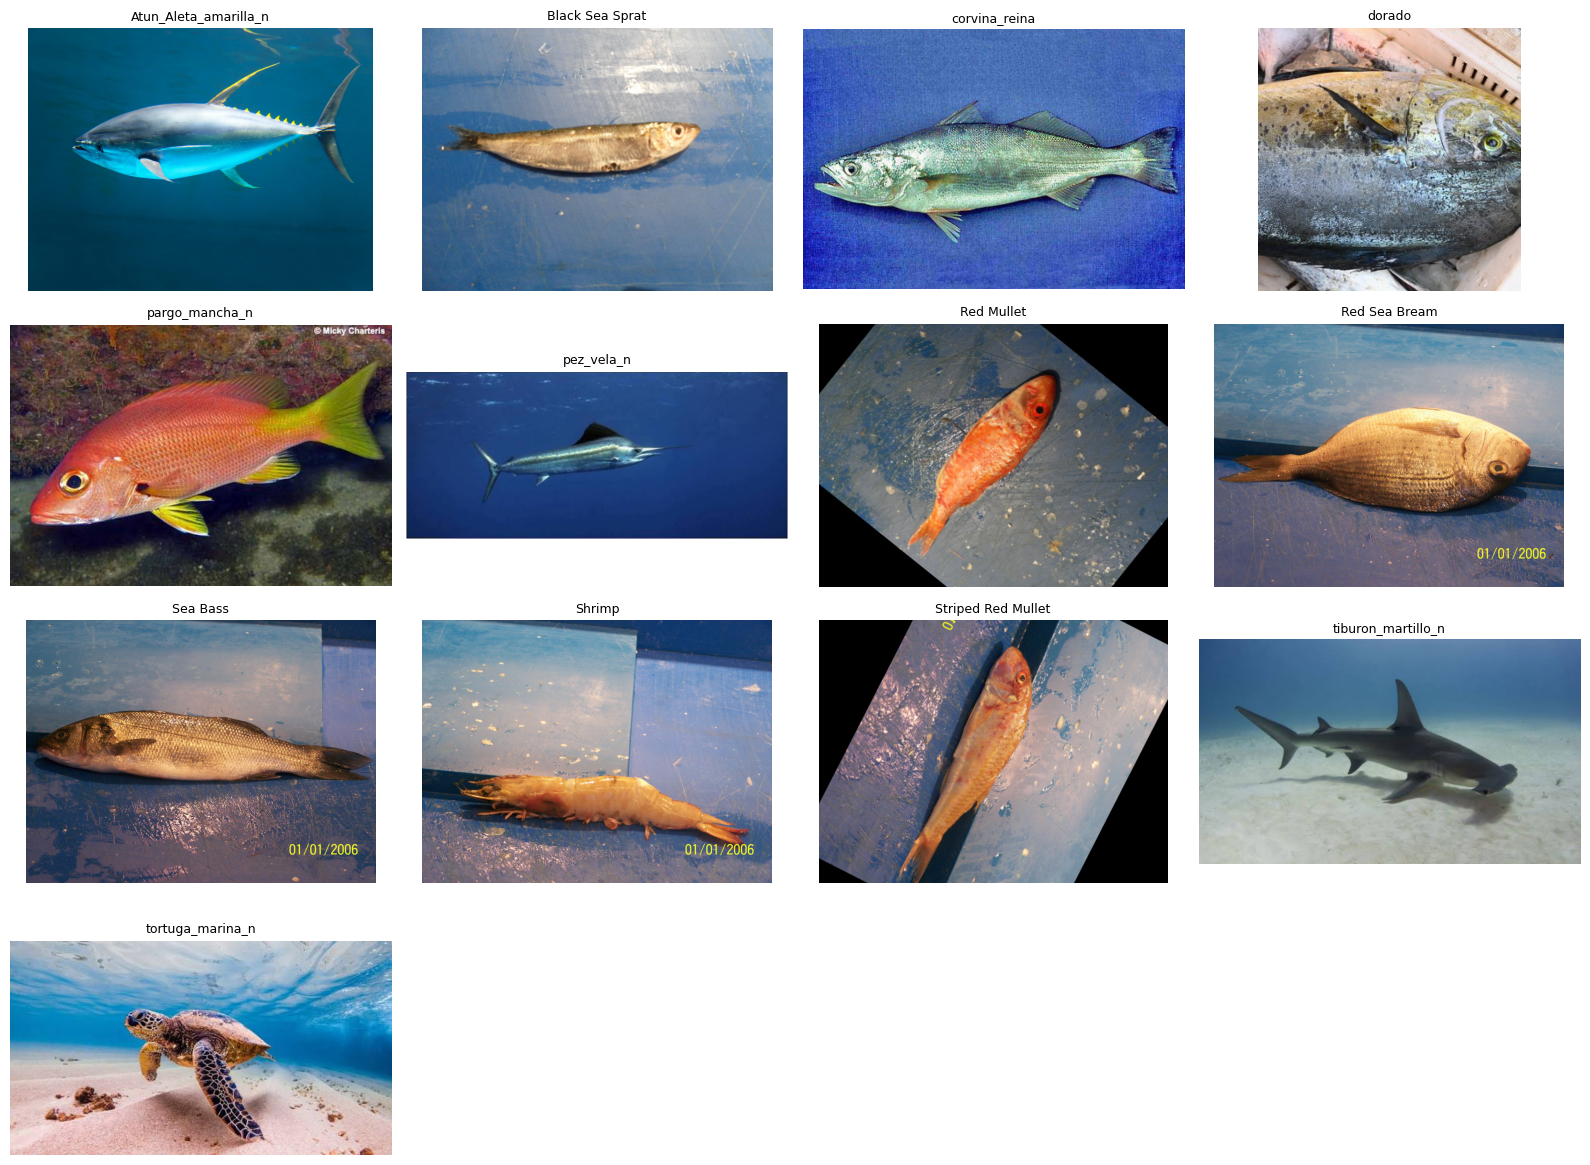

In [ ]:
# una imagen por clase
plt.figure(figsize=(16, 12))
i = 0
for clase in clases:
    carpeta_clase = os.path.join(mi_directorio, clase)
    img = None
    for fichero_imagen in os.listdir(carpeta_clase):
        ruta_imagen = os.path.join(carpeta_clase, fichero_imagen)
        try:
            img = imread(ruta_imagen)
            break
        except Exception:
            continue

    if img is None:
        continue

    i += 1
    plt.subplot(4, 4, i)
    plt.imshow(img)
    plt.title(clase, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3.2 Resolución de las imágenes

In [ ]:
image_shape = (150, 150, 3)  
image_shape

(150, 150, 3)

## 3.3 Generación y aumento de datos

In [128]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_gen = ImageDataGenerator(
    rescale=1/255,
    horizontal_flip=True,
    validation_split=0.2
)

In [129]:
batch_size = 32

In [130]:
#train 
train_image_gen = image_gen.flow_from_directory(
    mi_directorio,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',  
    subset='training',
    shuffle=True
)

Found 597 images belonging to 13 classes.


In [131]:
# validation
test_image_gen = image_gen.flow_from_directory(
    mi_directorio,
    target_size=image_shape[:2],
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 146 images belonging to 13 classes.


In [132]:
train_image_gen.class_indices

{'Atun_Aleta_amarilla_n': 0,
 'Black Sea Sprat': 1,
 'Red Mullet': 2,
 'Red Sea Bream': 3,
 'Sea Bass': 4,
 'Shrimp': 5,
 'Striped Red Mullet': 6,
 'corvina_reina': 7,
 'dorado': 8,
 'pargo_mancha_n': 9,
 'pez_vela_n': 10,
 'tiburon_martillo_n': 11,
 'tortuga_marina_n': 12}

# 4. Creación del modelo (CNN multiclase)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam

model = Sequential()

# Bloque convolucional 1
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=image_shape, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloque convolucional 2
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloque convolucional 3
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Aplanado del mapa de características
model.add(Flatten())

# Clasificador
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Capa de salida
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.0005),
              metrics=['accuracy'])

c:\Users\steven16\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [134]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,566,797 (36.49 MB)

 Trainable params: 9,566,797 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

# 5. Entrenamiento del modelo

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

# Reduce el learning rate ante un estancamiento     
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [136]:
results = model.fit(
    train_image_gen,
    epochs=30,
    validation_data=test_image_gen,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1558 - loss: 2.4822 - val_accuracy: 0.2260 - val_loss: 2.1659 - learning_rate: 5.0000e-04
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 800ms/step - accuracy: 0.3300 - loss: 2.0024 - val_accuracy: 0.4932 - val_loss: 1.6742 - learning_rate: 5.0000e-04
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 807ms/step - accuracy: 0.4590 - loss: 1.6148 - val_accuracy: 0.5479 - val_loss: 1.2417 - learning_rate: 5.0000e-04
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 778ms/step - accuracy: 0.5846 - loss: 1.3252 - val_accuracy: 0.7192 - val_loss: 1.1085 - learning_rate: 5.0000e-04
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 771ms/step - accuracy: 0.6399 - loss: 1.1134 - val_accuracy: 0.7329 - val_loss: 0.8730 - learning_rate: 5.0000e-04
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 778ms/step - accuracy: 0.7102 - loss: 0.9637 - val_accuracy: 0.7740 - val_loss: 0.7995 - learning_rate: 5.0000e-04
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 787ms/step - accura

In [137]:
model.save('modelo_CNnN_peces.h5')

In [138]:
losses = pd.DataFrame(results.history)

<Axes: title={'center': 'Función de pérdida'}>

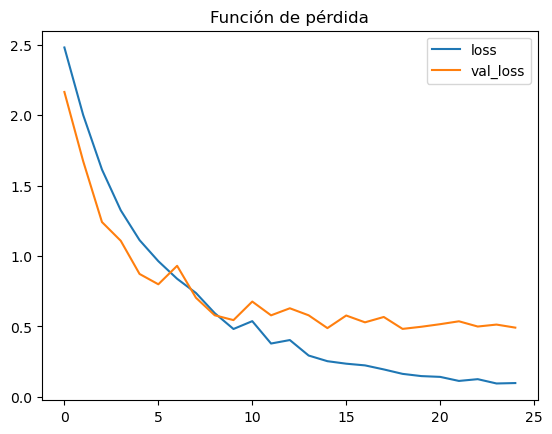

In [139]:
losses[['loss', 'val_loss']].plot(title='Función de pérdida')

<Axes: title={'center': 'Precisión (accuracy)'}>

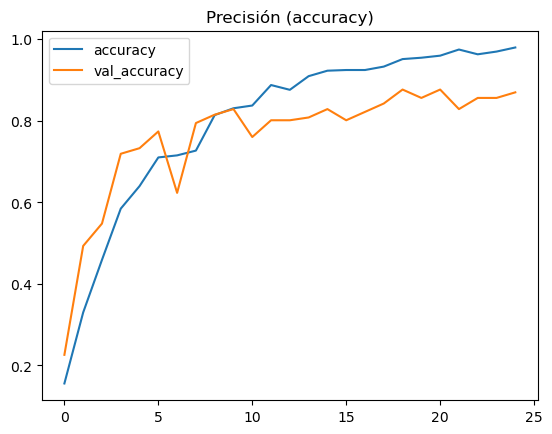

In [140]:
losses[['accuracy', 'val_accuracy']].plot(title='Precisión (accuracy)')

# 6. Evaluación del modelo

## 6.1 Desempeño sobre el conjunto de validación

In [141]:
model.evaluate(test_image_gen)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 440ms/step - accuracy: 0.8836 - loss: 0.5108


[0.5108131766319275, 0.8835616707801819]

In [142]:
# Predicción sobre el conjunto de validación
pred_probabilities = model.predict(test_image_gen)
predictions = np.argmax(pred_probabilities, axis=-1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step


In [143]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test_image_gen.classes, predictions,
                             target_names=list(train_image_gen.class_indices.keys())))

                       precision    recall  f1-score   support

Atun_Aleta_amarilla_n       0.67      0.67      0.67         6
      Black Sea Sprat       1.00      0.80      0.89        10
           Red Mullet       0.95      1.00      0.97        19
        Red Sea Bream       1.00      0.80      0.89        10
             Sea Bass       0.90      0.90      0.90        10
               Shrimp       0.90      0.90      0.90        10
   Striped Red Mullet       0.85      0.94      0.89        18
        corvina_reina       0.78      0.78      0.78         9
               dorado       0.80      0.75      0.77        16
       pargo_mancha_n       0.89      0.89      0.89         9
           pez_vela_n       0.85      0.92      0.88        12
   tiburon_martillo_n       0.73      0.89      0.80         9
     tortuga_marina_n       1.00      0.88      0.93         8

             accuracy                           0.87       146
            macro avg       0.87      0.85      0.86 

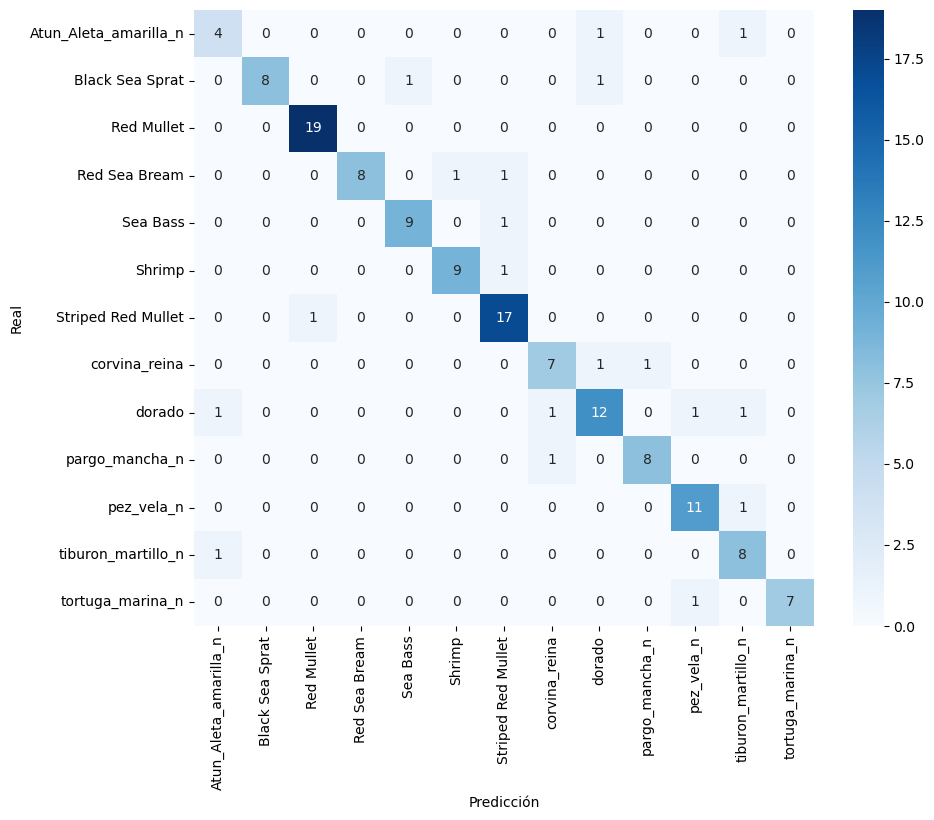

In [144]:
cm = confusion_matrix(test_image_gen.classes, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=list(train_image_gen.class_indices.keys()),
            yticklabels=list(train_image_gen.class_indices.keys()),
            cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()